# Predicción de ataque cardiaco empleando un Árbol de Clasificación

In [1]:
# Importar las librerias

# Cargamos nuestras librerias
import numpy as np
import pandas as pd

# Entorno SciKit Learn
from sklearn.tree import DecisionTreeClassifier   # Algortimo CART para árboles.

from sklearn.model_selection import train_test_split  # Dividir el conjunto de prueba y entrenamiento
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score # Validación cruzada
from sklearn.model_selection import cross_validate # Validación cruzada
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

# Para preprocesamiento
from sklearn.preprocessing import StandardScaler,MinMaxScaler  # La libreria para reescalar datos

In [2]:
datos=pd.read_csv("heart_attack.csv")

In [3]:
datos.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
0,63,1,3,145,233,1,0,150,0,0,1
1,37,1,2,130,250,0,1,187,0,0,1
2,41,0,1,130,204,0,0,172,0,0,1
3,56,1,1,120,236,0,1,178,0,0,1
4,57,0,0,120,354,0,1,163,1,0,1


In [4]:
# Preprocesamiento: Crear las dummies para las variables categoricas
# Seleccionamos el target
y=datos.output
# Atributos 
del datos["output"]
X=datos
X=pd.get_dummies(X, columns=["sex","cp","fbs","restecg","exng"])

In [5]:
X.head()

,age,trtbps,chol,thalachh,caa,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,fbs_0,fbs_1,restecg_0,restecg_1,restecg_2,exng_0,exng_1
0,63,145,233,150,0,0,1,0,0,0,1,0,1,1,0,0,1,0
1,37,130,250,187,0,0,1,0,0,1,0,1,0,0,1,0,1,0
2,41,130,204,172,0,1,0,0,1,0,0,1,0,1,0,0,1,0
3,56,120,236,178,0,0,1,0,1,0,0,1,0,0,1,0,1,0
4,57,120,354,163,0,1,0,1,0,0,0,1,0,0,1,0,0,1


In [6]:
# Dividir al conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.20,random_state=1234)
# Definir el modelo
modelo=DecisionTreeClassifier()
# Entrenamos el modelo.
modelo.fit(X_train, y_train)

DecisionTreeClassifier()

In [7]:
# predicciones
y_pred=modelo.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.64      0.65        28
           1       0.71      0.73      0.72        33

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



In [8]:
#¿Qué tan bien predice el modelo utilizando los datos de entrenamiento?...
y_pred_train=modelo.predict(X_train)
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       132

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242



In [9]:
# La importancia, de notar esta diferencia en las métricas es porque identificamos
# que el modelo está sobreajustado. 
# Vamos a ver algunas estrategias para evitar que el modelo se sobreajuste.

In [10]:
# Calibración del modelo... 
espacio_param={"max_depth":[3,4,5,6]}
# Definimos el modelo que vamos a ajustar
modelo=DecisionTreeClassifier()
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="accuracy", 
                              cv=10,n_jobs=-1)
#ajustamos los modelos
modelo_candidato.fit(X,y)
print("La mejor configuración fue:", modelo_candidato.best_params_)
print("La mejor métrica es:", modelo_candidato.best_score_)

La mejor configuración fue: {'max_depth': 4}
La mejor métrica es: 0.7817204301075269


In [11]:
# Combinaciones de criterios

In [12]:
# Calibración del modelo... 
espacio_param={"max_depth":[3,4,5,6,7,8,10],"min_samples_leaf":[5,10,15,20]}
# Definimos el modelo que vamos a ajustar
modelo=DecisionTreeClassifier()
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="accuracy", 
                              cv=10,n_jobs=-1)
#ajustamos los modelos
modelo_candidato.fit(X,y)
print("La mejor configuración fue:", modelo_candidato.best_params_)
print("La mejor métrica es:", modelo_candidato.best_score_)

La mejor configuración fue: {'max_depth': 6, 'min_samples_leaf': 10}
La mejor métrica es: 0.797956989247312


In [13]:
# Empleamos el parámetro de complejidad

In [40]:
# Calibración del modelo... 
espacio_param={"ccp_alpha":[0.01,0.05,0.1,0.5,0.7,1,1.5,2]}
# Definimos el modelo que vamos a ajustar
modelo=DecisionTreeClassifier(criterion="entropy")               #<- Cambiamos al criterio de Entropia
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="accuracy", 
                              cv=10,n_jobs=-1)
#ajustamos los modelos
modelo_candidato.fit(X,y)
print("La mejor configuración fue:", modelo_candidato.best_params_)
print("La mejor métrica es:", modelo_candidato.best_score_)

La mejor configuración fue: {'ccp_alpha': 0.05}
La mejor métrica es: 0.7687096774193549


In [15]:
# Cómo se ve un árbol....
modelo=DecisionTreeClassifier(max_depth=3)
modelo.fit(X,y)

DecisionTreeClassifier(max_depth=3)

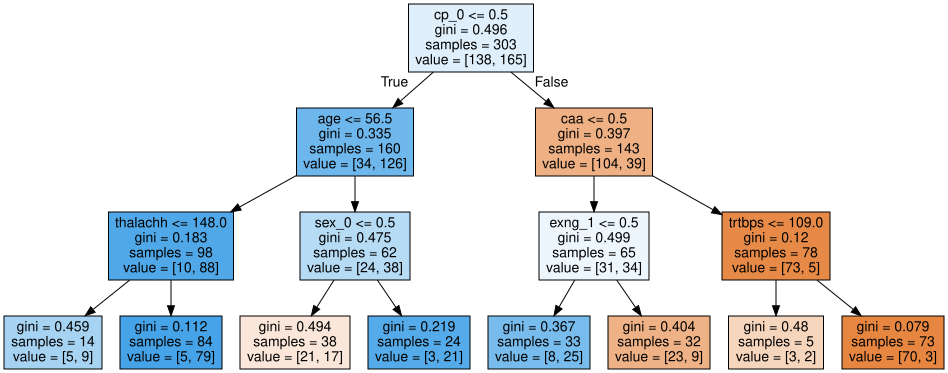

In [16]:
# desde el anaconda prompt (como administradores) ejecutan
# pip install graphviz
import graphviz
from sklearn import tree

dot_data=tree.export_graphviz(modelo,out_file=None,feature_names=X.columns, filled=True)

#Dibujamos el árbol
grafico=graphviz.Source(dot_data,format="png")
grafico

# Importancia de los atributos

In [39]:
importancia=pd.DataFrame()
importancia["Atributos"]=X.columns
importancia["importance"]=pd.DataFrame(np.array(modelo.feature_importances_))
importancia.sort_values(by="importance",ascending=False)

,Atributos,importance
7,cp_0,0.518309
4,caa,0.193461
17,exng_1,0.095478
0,age,0.079929
5,sex_0,0.069677
3,thalachh,0.027533
1,trtbps,0.015613
6,sex_1,0.000000
2,chol,0.000000
8,cp_1,0.000000


In [18]:
X.columns

Index(['age', 'trtbps', 'chol', 'thalachh', 'caa', 'sex_0', 'sex_1', 'cp_0',
       'cp_1', 'cp_2', 'cp_3', 'fbs_0', 'fbs_1', 'restecg_0', 'restecg_1',
       'restecg_2', 'exng_0', 'exng_1'],
      dtype='object')